SISTECH 2026 — MLOps Hands-On 1
## Membangun Fondasi Sistem Prediksi **Risk Score** (Chicago Crimes)

Selamat datang di Hands-On pertama **Machine Learning Operations** SISTECH 2026! 🎉

Notebook ini adalah **tutorial referensi**. Tugasnya memandu kalian mengubah data
kejahatan mentah menjadi sebuah **dataset fitur + label** yang siap dimodelkan di Hands-On 2.
Target akhirnya adalah sebuah **Risk Score (0–100)** yang menggambarkan tingkat risiko
sebuah lokasi pada waktu tertentu, berdasarkan pola kejahatan historis.

**Alur yang akan kita lalui:**
1. Setup & load dataset (Chicago Crimes)
2. Pembersihan data
3. **EDA** — memahami pola kejahatan lintas *waktu* dan *lokasi*
4. **Feature Engineering** — temporal (cyclical encoding) & spasial (grid aggregation)
5. **Pseudo-Labeling** — severity scoring + temporal decay + agregasi spasial → Risk Score
6. Menyusun & menyimpan dataset akhir (CSV/Parquet)

> 🧭 **Prinsip inti:** *data as foundation.* Model secanggih apa pun tidak berguna bila
> dibangun di atas data yang buruk. Tahap ini bukan sekadar "persiapan" — ini penentu
> keberhasilan seluruh sistem.

---

> ## ⚠️ Cara memakai notebook ini — BACA DULU
>
> Notebook ini **sengaja dibuat sebagai versi paling sederhana (naif).** Ia berjalan
> dari atas sampai bawah dan menghasilkan dataset akhir, **tapi banyak keputusannya
> sengaja dibuat seadanya** supaya kalian bisa melihat *mekanismenya bekerja* — bukan
> supaya kalian menyalinnya bulat-bulat.
>
> Sepanjang notebook kalian akan menemukan dua jenis blok:
> - 🔧 **Versi Sederhana (Baseline)** — kode yang berfungsi tapi jelas belum optimal.
> - 🙋 **Giliran Kalian** — di sinilah kalian mengambil alih: mengembangkan, mengganti,
>   atau memperbaiki versi sederhana tadi, lalu **menjustifikasinya di laporan**.
>
> Bagian yang paling dinilai (severity scoring & pemodelan relevansi waktu–lokasi) justru
> yang paling "mentah" di sini. Itu disengaja. **Nilai kalian datang dari seberapa jauh kalian
> mengembangkannya, bukan dari menjalankan notebook ini apa adanya.**

# 0. Installation & Setup

Kita hanya butuh stack data science standar: `pandas`, `numpy`, `matplotlib`, `seaborn`,
`scikit-learn`, dan `gdown` (untuk mengunduh dataset dari Google Drive).

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Setup selesai ✅")

Setup selesai ✅


# 1. Download & Import Dataset

Kita memakai dataset **Chicago Crimes**. Kolom-kolom penting untuk kita:
`Date`, `Primary Type`, `Description`, `Latitude`, `Longitude`, `Arrest`, `Location Description`.

> 📦 **Dataset asli sangat besar** (jutaan baris). Sesuai anjuran di dokumen, kita akan
> **mengambil subset** agar komputasi ringan. **Jelaskan pilihan subset kalian di laporan.**

In [32]:
import pandas as pd

usecols = [
    "ID", "Date", "Primary Type", "Description",
    "Location Description", "Arrest",
    "Latitude", "Longitude", "Year"
]

df = pd.read_csv(
    "dataset/chicago_crimes.csv",
    usecols=usecols
)

print("Shape mentah:", df.shape)
df.head()

Shape mentah: (8534663, 9)


,ID,Date,Primary Type,Description,Location Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,2026,41.954538,-87.651148


### 🙋 Giliran Kalian — Tentukan Subset

Dataset ini bisa sangat besar. Contoh strategi subset (pilih & **justifikasi**):
- **Rentang tahun** tertentu (mis. 3 tahun terakhir agar pola relevan dengan kondisi terkini).
- **Area** tertentu (mis. satu *District* atau bounding box tertentu).

Di bawah ini kita contohkan subset **3 tahun terakhir** yang tersedia di data. Ini keputusan
desain pertama kalian — ukuran & cakupan subset memengaruhi seluruh analisis berikutnya.

In [33]:
if "Year" in df.columns:
    last_year = int(df["Year"].max())
    df = df[df["Year"] >= last_year - 2].copy()
    print(f"Subset {last_year-2}-{last_year}. Shape:", df.shape)

Subset 2024-2026. Shape: (553919, 9)


# 2. Pembersihan Data

Langkah cleaning ini kita sediakan **cukup lengkap** — karena bukan fokus penilaian
hands-on ini, dan kalian butuh data yang bersih sebagai titik awal yang benar. Yang kita lakukan:
- **Parse kolom `Date`** menjadi tipe datetime (format Chicago: `MM/DD/YYYY HH:MM:SS AM/PM`).
- **Buang baris tanpa koordinat / tanggal** — tanpa `Latitude`/`Longitude`, sebuah kejadian
  tidak bisa dipetakan ke grid spasial.
- **Filter koordinat di luar bounding box Chicago** (menyingkirkan koordinat rusak / 0,0).
- Turunkan kolom waktu dasar: `hour`, `dow` (day-of-week), `month`.

In [34]:
# Parse tanggal
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
# Buang baris tanpa koordinat / tanpa tanggal valid
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()

# Bounding box kasar wilayah Chicago -> singkirkan koordinat rusak
df = df[df["Latitude"].between(41.60, 42.05) &
        df["Longitude"].between(-87.95, -87.50)].copy()

# Fitur waktu dasar
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek        # 0 = Senin ... 6 = Minggu
df["month"] = df["Datetime"].dt.month

print(f"Dibuang {before - len(df):,} baris. Shape bersih: {df.shape}")
df[["Datetime", "Primary Type", "Description", "Latitude", "Longitude", "hour", "dow"]].head()

Dibuang 3,023 baris. Shape bersih: (550896, 13)


,Datetime,Primary Type,Description,Latitude,Longitude,hour,dow
0,2026-04-11,THEFT,$500 AND UNDER,41.801025,-87.652621,0,5
2,2026-04-11,BATTERY,SIMPLE,41.884097,-87.675228,0,5
3,2026-04-11,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,41.977655,-87.697553,0,5
4,2026-04-11,THEFT,THEFT FROM MOTOR VEHICLE,41.954538,-87.651148,0,5
5,2026-04-11,BATTERY,SIMPLE,41.951894,-87.747276,0,5


# 3. Exploratory Data Analysis (EDA)

Tujuan EDA di sini: membangun **intuisi** tentang **kapan** dan **di mana** kejahatan
paling sering terjadi. Intuisi inilah yang nanti memandu keputusan feature engineering
dan pseudo-labeling.

Kita tunjukkan **beberapa contoh dasar** di bawah. Anggap ini titik awal — EDA yang baik
menggali lebih jauh dari sekadar menampilkan grafik.

## 3.1 Jenis Kejahatan Paling Umum

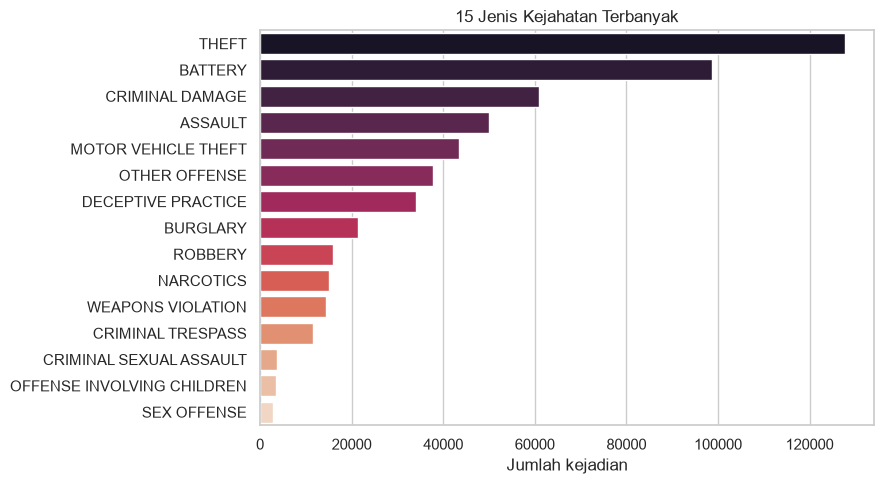

In [35]:
top_types = df["Primary Type"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_types.values, y=top_types.index, hue=top_types.index,
            palette="rocket", legend=False)
plt.title("15 Jenis Kejahatan Terbanyak")
plt.xlabel("Jumlah kejadian"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3.2 Pola Temporal — Jam, Hari, Bulan

Perhatikan baik-baik pola per **jam** dan per **hari**. Pola inilah yang membuat fitur
temporal menjadi penting.

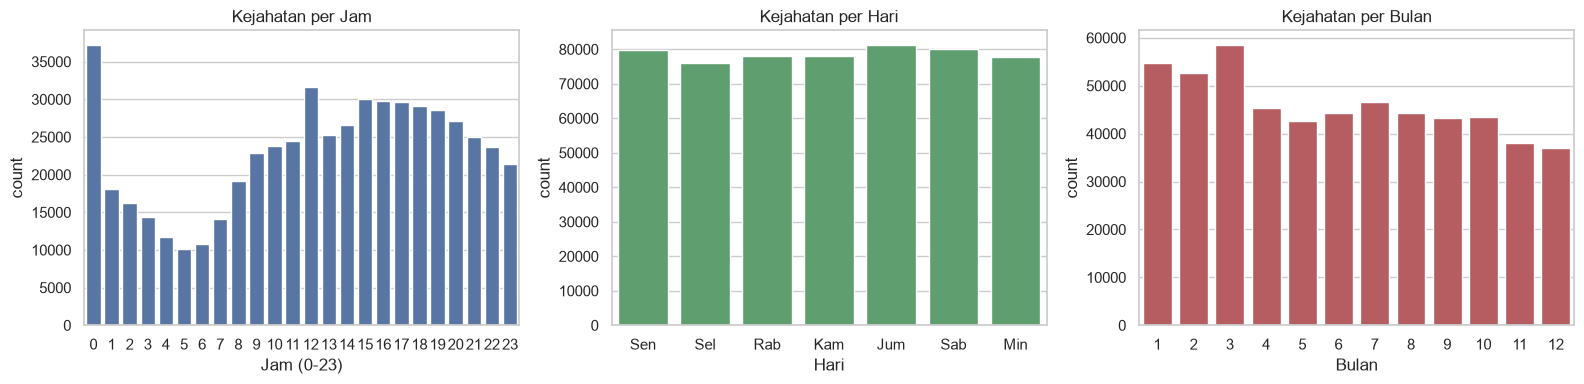

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per jam
sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

# Per hari dalam seminggu
labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

# Per bulan
sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan"); axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()

## 3.3 Pola Spasial — Hotspot

Sebaran koordinat memperlihatkan **konsentrasi** kejahatan. `hexbin` cocok untuk
menunjukkan kepadatan tanpa terganggu jutaan titik yang saling menimpa.

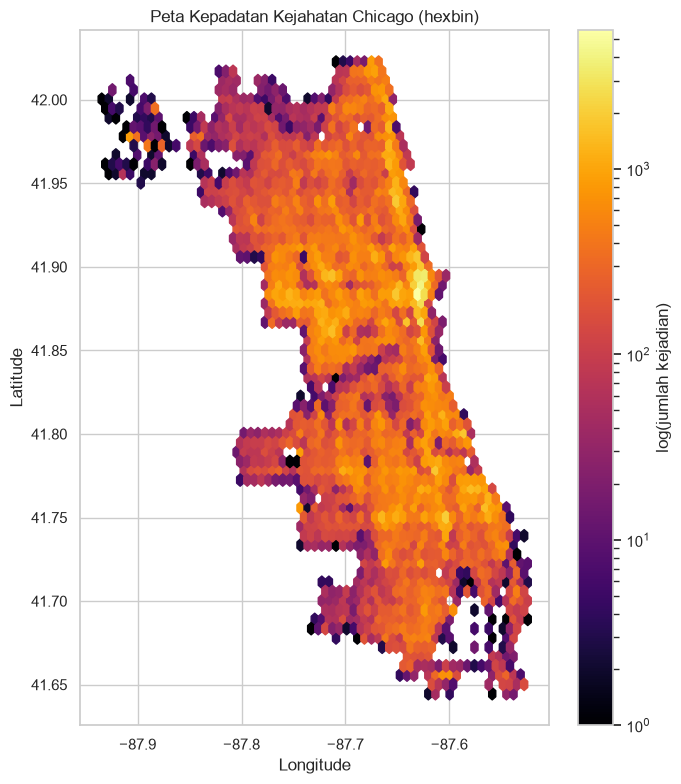

In [37]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan Chicago (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

### 🙋 Giliran Kalian — Gali Lebih Dalam

EDA di atas baru permukaan. Beberapa arah eksplorasi yang bisa **menemukan pola yang
belum terlihat** (dan nanti membantu kalian merancang fitur):
- Bagaimana pola **jam berbeda antara akhir pekan vs hari kerja**? (coba pisahkan)
- Apakah **jenis kejahatan tertentu** punya pola waktu/lokasi yang khas?
- Adakah **interaksi** antara dua dimensi (mis. hari × jam) yang tak terlihat bila dilihat terpisah?

> 📝 Tuliskan **pola paling menonjol** dari data kalian di laporan. Insight ini yang
> menjustifikasi kenapa kita butuh fitur temporal *dan* spasial.

### **1) Weekday vs Weekend — pola per jam**

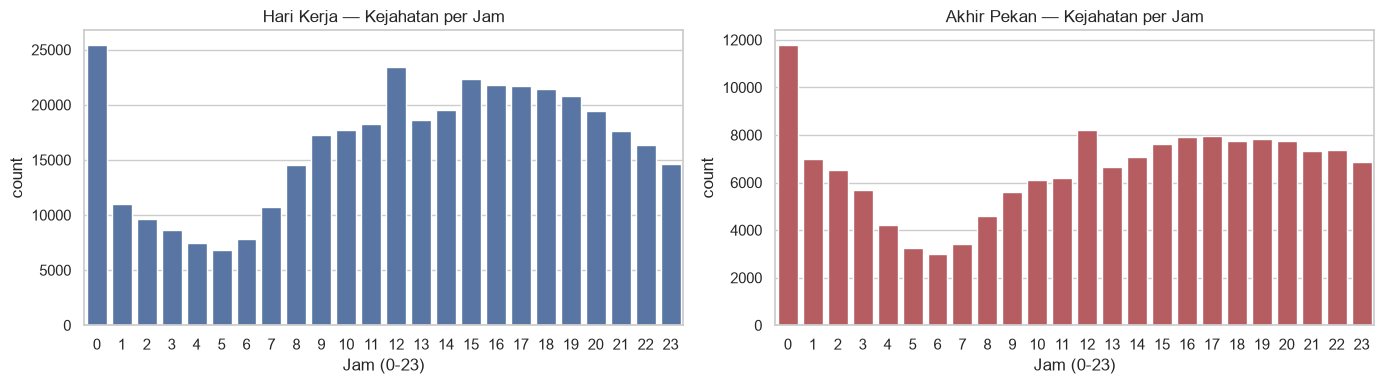

In [38]:
# Asumsi: kita bandingkan pola jam akhir pekan vs hari kerja,
# lalu lihat interaksi dow x hour, dan pola temporal untuk 5 jenis kejahatan teratas.

# 1) Weekday vs Weekend — pola per jam
df["is_weekend_tmp"] = df["dow"].isin([5, 6])  # Sabtu(5), Minggu(6)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x="hour", data=df[~df["is_weekend_tmp"]], ax=axes[0], color="#4C72B0")
axes[0].set_title("Hari Kerja — Kejahatan per Jam")
axes[0].set_xlabel("Jam (0-23)")

sns.countplot(x="hour", data=df[df["is_weekend_tmp"]], ax=axes[1], color="#C44E52")
axes[1].set_title("Akhir Pekan — Kejahatan per Jam")
axes[1].set_xlabel("Jam (0-23)")

plt.tight_layout(); plt.show()
df.drop(columns=["is_weekend_tmp"], inplace=True)

### **2) Interaksi Hari x Jam (heatmap) — pola yang tak terlihat kalau dipisah**

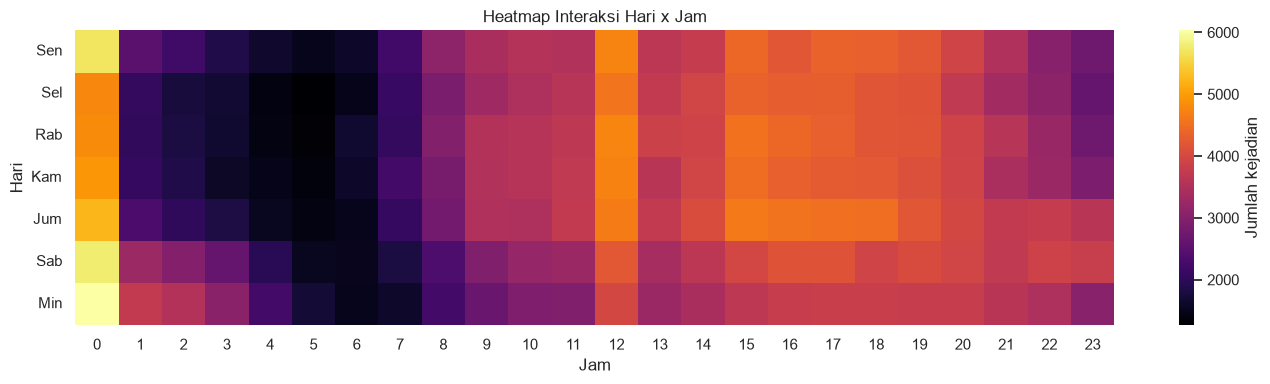

In [39]:
# 2) Interaksi Hari x Jam (heatmap) — pola yang tak terlihat kalau dipisah
pivot_dow_hour = df.pivot_table(index="dow", columns="hour", values="ID", aggfunc="count")

labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]

plt.figure(figsize=(14, 4))
sns.heatmap(pivot_dow_hour, cmap="inferno", cbar_kws={"label": "Jumlah kejadian"})
plt.yticks(np.arange(7) + 0.5, labels_dow, rotation=0)
plt.title("Heatmap Interaksi Hari x Jam")
plt.xlabel("Jam"); plt.ylabel("Hari")
plt.tight_layout(); plt.show()

### **3) Pola temporal untuk 5 jenis kejahatan teratas — apakah tiap jenis punya "jam sibuk" sendiri?**

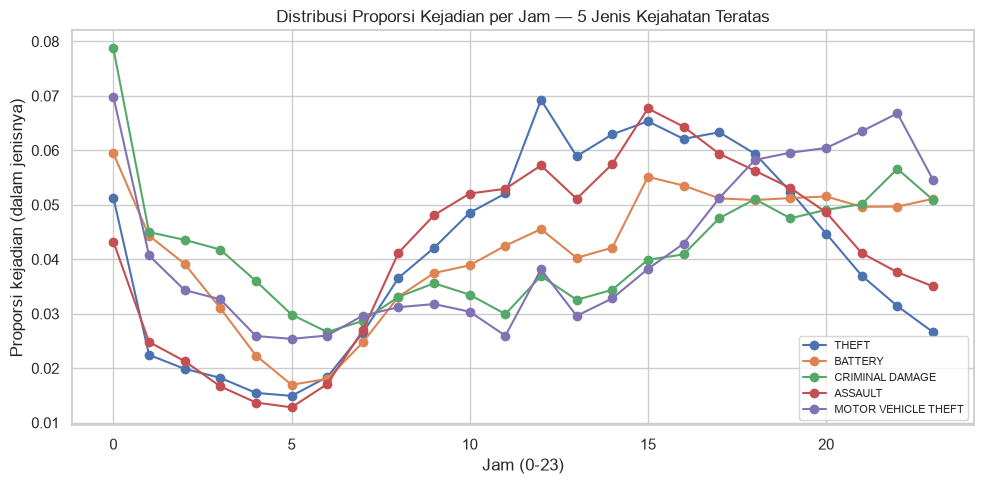

In [40]:
# 3) Pola temporal untuk 5 jenis kejahatan teratas — apakah tiap jenis punya "jam sibuk" sendiri?
top5_types = df["Primary Type"].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
for crime_type in top5_types:
    subset = df[df["Primary Type"] == crime_type]
    hourly_dist = subset["hour"].value_counts(normalize=True).sort_index()
    ax.plot(hourly_dist.index, hourly_dist.values, marker="o", label=crime_type)

ax.set_title("Distribusi Proporsi Kejadian per Jam — 5 Jenis Kejahatan Teratas")
ax.set_xlabel("Jam (0-23)"); ax.set_ylabel("Proporsi kejadian (dalam jenisnya)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 4. Feature Engineering

Kita akan membangun dua kelompok fitur:
- **Temporal** — merepresentasikan sifat **siklikal** waktu.
- **Spasial** — mengagregasi lokasi kontinu menjadi **grid** yang bisa dibandingkan.

## 4.1 Fitur Temporal — Cyclical Encoding

Waktu bersifat **siklikal**: jam `23:00` sebenarnya *berdekatan* dengan `00:00`, tetapi
jika kita pakai angka mentah (`23` vs `0`) model akan menganggapnya **berjauhan**
(selisih 23!). Solusi umum: petakan setiap nilai siklikal ke **lingkaran** dengan `sin` & `cos`:

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).

> Ini salah satu bagian yang memang kita tunjukkan cukup utuh, karena konsepnya
> penting dipahami benar. Tapi **apakah semua fitur waktu ini perlu dipakai?** Itu
> tetap keputusan kalian (lihat "Giliran Kalian" di bawah).

In [41]:
def cyclical_encode(values, period):
    # Ubah nilai siklikal menjadi pasangan (sin, cos)
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dow_sin"],  df["dow_cos"]  = cyclical_encode(df["dow"],  7)

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()

,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,0,0.0,1.0,5,-0.974928,-0.222521
2,0,0.0,1.0,5,-0.974928,-0.222521
3,0,0.0,1.0,5,-0.974928,-0.222521
4,0,0.0,1.0,5,-0.974928,-0.222521
5,0,0.0,1.0,5,-0.974928,-0.222521


**Bukti bahwa encoding ini benar.** Kita cek jarak antar-jam pada bidang (sin, cos):
`23:00` seharusnya lebih dekat ke `00:00` daripada ke `12:00`.

Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


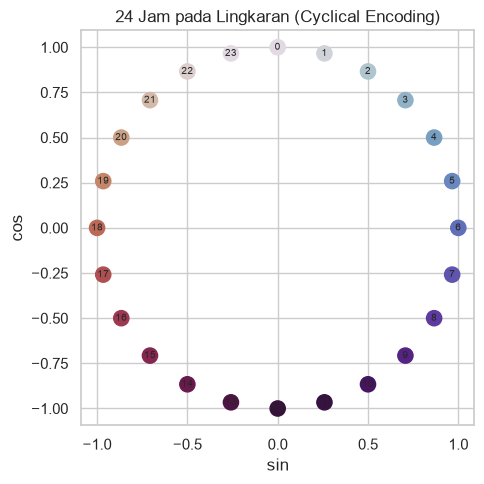

In [42]:
def point(v, p): return np.array(cyclical_encode(np.array([v]), p)).ravel()

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")

# Visualisasi 24 jam sebagai lingkaran
hs, hc = cyclical_encode(np.arange(24), 24)
plt.figure(figsize=(5,5))
plt.scatter(hs, hc, c=np.arange(24), cmap="twilight", s=120)
for h in range(24):
    plt.annotate(str(h), (hs[h], hc[h]), ha="center", va="center", fontsize=7)
plt.title("24 Jam pada Lingkaran (Cyclical Encoding)")
plt.xlabel("sin"); plt.ylabel("cos"); plt.axis("equal")
plt.tight_layout(); plt.show()

## 4.2 Fitur Spasial — Grid Aggregation

Koordinat lintang/bujur bersifat **kontinu & presisi tinggi** — dua titik yang selisihnya
sangat kecil praktis berada di lingkungan yang sama. Agar lokasi bisa **diagregasi dan
dibandingkan**, cara paling sederhana adalah **membulatkan koordinat** ke beberapa desimal,
sehingga titik-titik yang berdekatan jatuh ke *sel* yang sama.

> 🔧 **Versi Sederhana (Baseline).** Kita bulatkan koordinat ke 2 desimal (± 1 km per sel).
> Ini cara paling lugas untuk membentuk grid — tapi juga paling kasar.

In [43]:
# Versi sederhana: bulatkan koordinat -> cell_id
ROUND_DECIMALS = 2   # 2 desimal ~ 1.1 km. Makin besar angka -> sel makin kecil.

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik: {df['cell_id'].nunique():,}")
df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()

Jumlah sel unik: 726


,Latitude,Longitude,lat_r,lon_r,cell_id
0,41.801025,-87.652621,41.80,-87.65,41.8_-87.65
2,41.884097,-87.675228,41.88,-87.68,41.88_-87.68
3,41.977655,-87.697553,41.98,-87.70,41.98_-87.7
4,41.954538,-87.651148,41.95,-87.65,41.95_-87.65
5,41.951894,-87.747276,41.95,-87.75,41.95_-87.75


### 🙋 Giliran Kalian — Feature Engineering

Versi di atas sengaja minimal. Ruang eksplorasi yang terbuka lebar:
- **Ukuran sel**: pembulatan 2 desimal itu kasar. Apakah grid lebih halus lebih baik?
  Apa konsekuensinya (sel kosong, komputasi)? Adakah cara membentuk grid selain pembulatan?
- **Fitur turunan**: dari data mentah, fitur agregat apa lagi yang mungkin berguna untuk
  memprediksi risiko? (pikirkan: frekuensi kejadian, proporsi kejadian tertentu, dst.)
- **Fitur temporal**: apakah `month` perlu? Apakah penanda akhir pekan berguna?

> Setiap fitur yang kalian tambah/ubah **harus dijustifikasi** — kenapa itu masuk akal
> untuk memprediksi risiko, bukan sekadar "karena bisa dibuat".

In [44]:
# Asumsi:
# - Grid diperhalus dari 2 -> 3 desimal (~1.1km -> ~110m per sel). Konsekuensinya: sel makin banyak
#   dan makin banyak sel yang sepi kejadian (sparse), tapi resolusi lokasi jauh lebih relevan
#   untuk risiko "titik lokasi", bukan cuma "area besar".
# - Tambah fitur is_weekend (akhir pekan punya pola berbeda, lihat EDA di atas).
# - Tambah fitur is_violent sebagai penanda kejahatan dengan risiko fisik tinggi -> nanti
#   diagregasi jadi 'violent_share' per unit (proporsi kejadian kekerasan di sel tsb).

ROUND_DECIMALS = 3   # 3 desimal ~ 110m. Lebih halus dari baseline (2 desimal ~ 1.1km).

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik (grid {ROUND_DECIMALS} desimal): {df['cell_id'].nunique():,}")

# Cek tingkat kesparsitasan: berapa % sel yang cuma punya 1 kejadian?
cell_counts = df["cell_id"].value_counts()
pct_singleton = (cell_counts == 1).mean() * 100
print(f"Sel dengan hanya 1 kejadian: {pct_singleton:.1f}% dari total sel unik")
print("-> semakin halus grid, semakin sparse. Ini alasan kita butuh spatial smoothing di tahap 5.3.")

# Fitur weekend
df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)

# Fitur penanda kejahatan kekerasan (dipakai untuk fitur agregat 'violent_share' nanti)
VIOLENT_TYPES = {"HOMICIDE", "CRIM SEXUAL ASSAULT", "CRIMINAL SEXUAL ASSAULT",
                  "ROBBERY", "ASSAULT", "BATTERY", "KIDNAPPING", "ARSON"}
df["is_violent"] = df["Primary Type"].isin(VIOLENT_TYPES).astype(int)

df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id", "is_weekend", "is_violent"]].head()

Jumlah sel unik (grid 3 desimal): 38,330
Sel dengan hanya 1 kejadian: 12.7% dari total sel unik
-> semakin halus grid, semakin sparse. Ini alasan kita butuh spatial smoothing di tahap 5.3.


,Latitude,Longitude,lat_r,lon_r,cell_id,is_weekend,is_violent
0,41.801025,-87.652621,41.801,-87.653,41.801_-87.653,1,0
2,41.884097,-87.675228,41.884,-87.675,41.884_-87.675,1,1
3,41.977655,-87.697553,41.978,-87.698,41.978_-87.698,1,0
4,41.954538,-87.651148,41.955,-87.651,41.955_-87.651,1,0
5,41.951894,-87.747276,41.952,-87.747,41.952_-87.747,1,1


# 5. Pseudo-Labeling → Membentuk **Risk Score**

Dataset kejahatan **tidak** memiliki kolom "Risk Score" (tidak ada *ground truth*).
**Pseudo-labeling** adalah teknik membentuk label target dari **domain knowledge**.
Kita bangun Risk Score dalam beberapa langkah: **severity → temporal decay → spatial
aggregation → normalisasi 0–100**.

> 🎯 **Unit analisis** yang kita pakai di tutorial: **(sel grid × hari × jam)**. Ini
> menjawab langsung definisi *"risiko suatu lokasi pada waktu tertentu"*. **Kalian bebas
> memilih unit lain** (mis. per sel saja) — asalkan dijustifikasi.

> ⚠️ **Perhatian:** bagian inilah (severity + space-time decay) yang **paling dinilai**
> di hands-on ini (bobot 35%). Semua kode di bawah sengaja dibuat **sesederhana mungkin**
> supaya kalian melihat mekanismenya. Jangan berhenti di sini — kembangkan.

## 5.1 Severity Scoring

Setiap kejahatan diberi skor keparahan berdasarkan kombinasi **Primary Type + Description**.

> 🔧 **Versi Sederhana (Baseline).** Kita hanya mengisi **beberapa** kombinasi sebagai
> contoh, dan memberi **satu nilai default** untuk semua sisanya. Jalankan sel berikutnya,
> lalu lihat sendiri **berapa persen data yang jatuh ke nilai default** — itu bukti bahwa
> tabel sesederhana ini jelas belum memadai.

In [45]:
# Versi PALING SEDERHANA — hanya beberapa contoh untuk menunjukkan mekanismenya.
# Sadari: ratusan kombinasi Primary Type + Description lain akan jatuh ke DEFAULT.
# Inilah yang harus KALIAN kembangkan & justifikasi.
severity_table = {
    ("HOMICIDE", "FIRST DEGREE MURDER"): 100,
    ("ROBBERY", "ARMED: HANDGUN"):        82,
    ("BATTERY", "SIMPLE"):                50,
    ("THEFT", "$500 AND UNDER"):          20,
    ("CRIMINAL DAMAGE", "TO VEHICLE"):    12,
}
DEFAULT_SEVERITY = 30   # SEMUA kombinasi lain kena nilai ini — jelas terlalu kasar.

def lookup_severity(row):
    return severity_table.get((row["Primary Type"], row["Description"]), DEFAULT_SEVERITY)

df["severity"] = df.apply(lookup_severity, axis=1)

# Berapa banyak yang jatuh ke default? (indikator seberapa 'kasar' tabel kita)
pct_default = (df["severity"] == DEFAULT_SEVERITY).mean() * 100
print(f"Baris yang memakai nilai DEFAULT: {pct_default:.1f}%")
print("(Makin tinggi angka ini, makin banyak informasi keparahan yang kita 'ratakan'.)")
df[["Primary Type", "Description", "severity"]].head()

Baris yang memakai nilai DEFAULT: 80.6%
(Makin tinggi angka ini, makin banyak informasi keparahan yang kita 'ratakan'.)


,Primary Type,Description,severity
0,THEFT,$500 AND UNDER,20
2,BATTERY,SIMPLE,50
3,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,30
4,THEFT,THEFT FROM MOTOR VEHICLE,30
5,BATTERY,SIMPLE,50


### 🙋 Giliran Kalian — Severity Table

Ini **komponen inti pertama** yang dinilai. Kembangkan versi sederhana di atas:
- Perbanyak kombinasi yang tercakup (lihat `df["Primary Type"].value_counts()` &
  `df["Description"].value_counts()` untuk tahu mana yang paling sering muncul).
- Pertimbangkan strategi *fallback* yang lebih baik daripada satu angka default —
  misalnya default **per Primary Type**, bukan satu nilai untuk semuanya.
- **Justifikasi** skala nilai kalian berdasarkan konteks keamanan publik.

In [46]:
# Asumsi: daripada 1 default global untuk SEMUA kombinasi yang tak tercakup, kita pakai
# fallback bertingkat -> skor dasar per Primary Type (mencakup hampir seluruh jenis kejahatan
# di Chicago Crimes) (mis. ARMED/AGGRAVATED menaikkan skor, ATTEMPT menurunkan skor, nominal kerugian
# untuk kejahatan properti).

# --- Level 1: skor dasar per Primary Type (0-100), berdasarkan tingkat keparahan
#     terhadap keselamatan publik ---
primary_type_severity = {
    "HOMICIDE": 100,
    "CRIM SEXUAL ASSAULT": 95, "CRIMINAL SEXUAL ASSAULT": 95,
    "HUMAN TRAFFICKING": 90,
    "KIDNAPPING": 85,
    "ARSON": 78,
    "ROBBERY": 72,
    "WEAPONS VIOLATION": 65,
    "OFFENSE INVOLVING CHILDREN": 60,
    "ASSAULT": 55,
    "BATTERY": 50,
    "BURGLARY": 45,
    "STALKING": 42,
    "INTIMIDATION": 40,
    "MOTOR VEHICLE THEFT": 38,
    "INTERFERENCE WITH PUBLIC OFFICER": 25,
    "NARCOTICS": 28, "OTHER NARCOTIC VIOLATION": 28,
    "THEFT": 22,
    "CRIMINAL TRESPASS": 20,
    "CONCEALED CARRY LICENSE VIOLATION": 20,
    "DECEPTIVE PRACTICE": 18,
    "CRIMINAL DAMAGE": 15,
    "PROSTITUTION": 15,
    "PUBLIC PEACE VIOLATION": 15,
    "LIQUOR LAW VIOLATION": 10,
    "GAMBLING": 10,
    "OTHER OFFENSE": 20,
}
GLOBAL_DEFAULT = 25  

# --- Level 2: modifier berdasarkan kata kunci di Description ---
def severity_modifier(description: str) -> int:
    d = str(description).upper()
    mod = 0
    if "ARMED" in d or "AGGRAVATED" in d:
        mod += 20
    if "HANDGUN" in d or "FIREARM" in d or "GUN" in d:
        mod += 10
    if "ATTEMPT" in d:
        mod -= 15
    if "SIMPLE" in d:
        mod -= 5
    if "UNDER $500" in d or "$500 AND UNDER" in d or "$300 AND UNDER" in d:
        mod -= 8
    if "OVER $500" in d or "OVER $300" in d or "$500 TO $10,000" in d or "OVER $10,000" in d:
        mod += 8
    if "DOMESTIC" in d:
        mod += 5
    return mod

def lookup_severity_v2(row) -> float:
    base = primary_type_severity.get(row["Primary Type"], GLOBAL_DEFAULT)
    score = base + severity_modifier(row["Description"])
    return float(np.clip(score, 0, 100))

df["severity"] = df.apply(lookup_severity_v2, axis=1)

pct_unmapped_type = (~df["Primary Type"].isin(primary_type_severity)).mean() * 100
print(f"Primary Type yang TIDAK tercakup tabel (pakai GLOBAL_DEFAULT): {pct_unmapped_type:.2f}%")
print("(Bandingkan dengan baseline yang defaultnya bisa >50% — ini bukti tabel sekarang jauh lebih representatif.)")
print(df["severity"].describe().round(2))
df[["Primary Type", "Description", "severity"]].head(10)

Primary Type yang TIDAK tercakup tabel (pakai GLOBAL_DEFAULT): 0.55%
(Bandingkan dengan baseline yang defaultnya bisa >50% — ini bukti tabel sekarang jauh lebih representatif.)
count    550896.00
mean         36.10
std          21.53
min           3.00
25%          20.00
50%          30.00
75%          50.00
max         100.00
Name: severity, dtype: float64


,Primary Type,Description,severity
0,THEFT,$500 AND UNDER,14.0
2,BATTERY,SIMPLE,45.0
3,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,18.0
4,THEFT,THEFT FROM MOTOR VEHICLE,22.0
5,BATTERY,SIMPLE,45.0
6,CRIMINAL TRESPASS,TO LAND,20.0
7,THEFT,OVER $500,30.0
8,MOTOR VEHICLE THEFT,AUTOMOBILE,38.0
9,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,20.0
10,DECEPTIVE PRACTICE,ILLEGAL USE CASH CARD,18.0


## 5.2 Temporal Decay — Recency

Apakah kejahatan 3 tahun lalu perlu berkontribusi sebesar kejahatan kemarin? Umumnya
**tidak** — relevansi cenderung memudar seiring waktu.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai bentuk peluruhan **paling lugas**: bobot
> **linear** yang turun dari 1 (paling baru) hingga mendekati 0 (paling lama), berdasarkan
> umur kejadian. Ini gampang dipahami, tapi belum tentu bentuk terbaik.

In [47]:
REFERENCE_DATE = df["Datetime"].max()   # "sekarang" menurut data
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400

# Peluruhan LINEAR sederhana: 1.0 di hari terbaru -> ~0 di data tertua
max_age = df["age_days"].max()
df["w_time"] = 1 - (df["age_days"] / max_age)     # rentang 0..1

# Kontribusi tiap kejadian = severity x bobot recency
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"w_time range   : {df['w_time'].min():.3f} .. {df['w_time'].max():.3f}")
df[["Datetime", "age_days", "w_time", "severity", "event_value"]].head()

Reference date : 2026-04-11 00:00:00
w_time range   : 0.000 .. 1.000


,Datetime,age_days,w_time,severity,event_value
0,2026-04-11,0.0,1.0,14.0,14.0
2,2026-04-11,0.0,1.0,45.0,45.0
3,2026-04-11,0.0,1.0,18.0,18.0
4,2026-04-11,0.0,1.0,22.0,22.0
5,2026-04-11,0.0,1.0,45.0,45.0


### 🙋 Giliran Kalian — Bentuk Peluruhan Waktu

Ini bagian dari **komponen inti kedua** yang dinilai. Peluruhan linear itu pilihan
paling sederhana — dan punya kelemahan (mis. kejadian tertua bobotnya persis 0).
- Apakah bentuk lain lebih masuk akal? (mis. **eksponensial / half-life**, di mana
  relevansi turun setengah setiap periode tertentu?)
- Seberapa cepat relevansi *seharusnya* memudar untuk konteks kejahatan? Sebulan?
  Setahun? **Justifikasi** parameter kalian.

HALF_LIFE_DAYS = 180
w_time range   : 0.0408 .. 1.0000


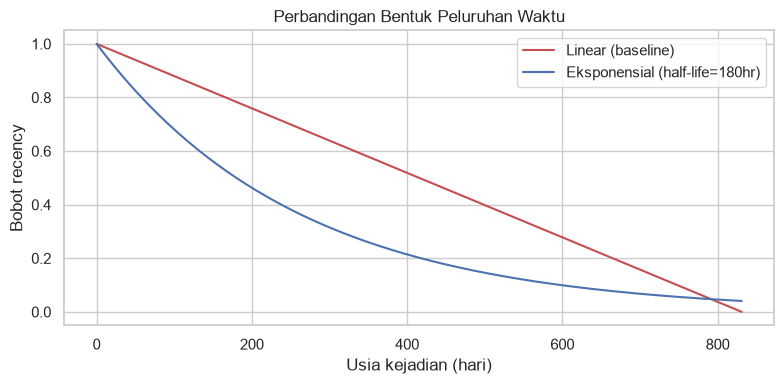

,Datetime,age_days,w_time,severity,event_value
0,2026-04-11,0.0,1.0,14.0,14.0
2,2026-04-11,0.0,1.0,45.0,45.0
3,2026-04-11,0.0,1.0,18.0,18.0
4,2026-04-11,0.0,1.0,22.0,22.0
5,2026-04-11,0.0,1.0,45.0,45.0


In [48]:
# Asumsi: peluruhan linear membuat kejadian tertua bobotnya PERSIS 0 (informasinya hilang total),
# padahal kejahatan lama tetap punya sedikit relevansi (pola lokasi cenderung persisten).
# Eksponensial/half-life lebih masuk akal: relevansi berkurang SEPARUH setiap periode tertentu,
# tapi tidak pernah benar-benar nol.

# HALF_LIFE_DAYS = 180 (~6 bulan): asumsi bahwa pola kejahatan di suatu lokasi cukup persisten
# dalam skala bulanan-tahunan, tapi kejadian setahun lalu relevansinya sudah tinggal ~25%.

HALF_LIFE_DAYS = 180

df["w_time"] = 0.5 ** (df["age_days"] / HALF_LIFE_DAYS)
df["event_value"] = df["severity"] * df["w_time"]

print(f"HALF_LIFE_DAYS = {HALF_LIFE_DAYS}")
print(f"w_time range   : {df['w_time'].min():.4f} .. {df['w_time'].max():.4f}")

# Bandingkan bentuk kurva linear (baseline) vs eksponensial
age_range = np.linspace(0, df["age_days"].max(), 200)
w_linear = 1 - (age_range / df["age_days"].max())
w_exp = 0.5 ** (age_range / HALF_LIFE_DAYS)

plt.figure(figsize=(8, 4))
plt.plot(age_range, w_linear, label="Linear (baseline)", color="#C44E52")
plt.plot(age_range, w_exp, label=f"Eksponensial (half-life={HALF_LIFE_DAYS}hr)", color="#4C72B0")
plt.title("Perbandingan Bentuk Peluruhan Waktu")
plt.xlabel("Usia kejadian (hari)"); plt.ylabel("Bobot recency")
plt.legend(); plt.tight_layout(); plt.show()

df[["Datetime", "age_days", "w_time", "severity", "event_value"]].head()

### Membentuk tabel unit analisis (sel × hari × jam)

Kita jumlahkan `event_value` (severity × recency) ke tiap unit analisis untuk membentuk
`base_value` — inilah bahan mentah Risk Score. Sekalian kita bawa satu **fitur agregat**
tambahan:

- **`crime_count`** — jumlah kejadian pada tiap unit. Ini fitur yang berbeda sifatnya dari
  `base_value`: ia menghitung *frekuensi* (berapa sering), sementara `base_value` menimbang
  *keparahan × kebaruan*. Sebuah sel bisa punya banyak kejadian ringan (count tinggi,
  severity rendah) atau sedikit kejadian berat — dan model nanti bisa belajar dari keduanya.

In [49]:
unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value  = ("event_value", "sum"),
               crime_count = ("ID", "size")))
print("Jumlah baris unit (sel × hari × jam):", f"{len(unit):,}")
unit.head()

Jumlah baris unit (sel × hari × jam): 457,696


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count
0,41.645_-87.54,41.645,-87.54,0,5,19.157729,1
1,41.645_-87.54,41.645,-87.54,0,9,10.367267,2
2,41.645_-87.54,41.645,-87.54,1,0,11.180426,1
3,41.645_-87.54,41.645,-87.54,1,9,43.896514,1
4,41.645_-87.54,41.645,-87.54,2,7,4.070746,1


In [50]:
# "Membentuk tabel unit analisis" -- ini melengkapi fitur is_violent & is_weekend
# yang sudah dibuat di tahap Feature Engineering, sekaligus arrest_rate sebagai sinyal tambahan
# (lokasi dengan arrest rate rendah bisa jadi indikasi risiko yang kurang tertangani).

extra_feats = (df.groupby(["cell_id", "dow", "hour"], as_index=False)
                 .agg(arrest_rate=("Arrest", "mean"),
                      violent_share=("is_violent", "mean")))

unit = unit.merge(extra_feats, on=["cell_id", "dow", "hour"], how="left")
unit["is_weekend"] = unit["dow"].isin([5, 6]).astype(int)

print("Kolom unit sekarang:", list(unit.columns))
unit[["cell_id", "dow", "hour", "base_value", "crime_count",
      "arrest_rate", "violent_share", "is_weekend"]].head()

Kolom unit sekarang: ['cell_id', 'lat_r', 'lon_r', 'dow', 'hour', 'base_value', 'crime_count', 'arrest_rate', 'violent_share', 'is_weekend']


,cell_id,dow,hour,base_value,crime_count,arrest_rate,violent_share,is_weekend
0,41.645_-87.54,0,5,19.157729,1,0.0,0.0,0
1,41.645_-87.54,0,9,10.367267,2,0.0,0.0,0
2,41.645_-87.54,1,0,11.180426,1,1.0,1.0,0
3,41.645_-87.54,1,9,43.896514,1,0.0,1.0,0
4,41.645_-87.54,2,7,4.070746,1,0.0,0.0,0


## 5.3 Spatial Aggregation — Proximity

Risiko sebuah titik idealnya **tidak hanya** ditentukan oleh kejahatan tepat di sel itu —
area di sekitarnya juga relevan. Menyebarkan pengaruh antar-sel tetangga (*spatial smoothing*)
adalah teknik yang umum.

> 🔧 **Versi Sederhana (Baseline).** Kita lakukan penghalusan spasial **paling kasar**:
> untuk tiap sel, ambil **rata-rata `base_value` sel itu sendiri + 8 sel tetangga langsung**
> (grid 3×3 di sekelilingnya), pada irisan hari×jam yang sama. Kita pakai indeks grid dari
> koordinat bulat — **tanpa perhitungan jarak sesungguhnya**. Sederhana, jalan, dan sudah
> menangkap ide "tetangga ikut berpengaruh" — tapi masih kasar (semua tetangga dibobot sama,
> radius tetap 1 sel).

In [51]:
# Indeks grid integer dari koordinat bulat -> memudahkan mencari tetangga langsung
STEP = 10 ** (-ROUND_DECIMALS)                      # jarak antar-sel (0.01 utk 2 desimal)
unit["gx"] = (unit["lat_r"] / STEP).round().astype(int)
unit["gy"] = (unit["lon_r"] / STEP).round().astype(int)

# Lookup cepat: (gx, gy, dow, hour) -> base_value
base_lookup = unit.set_index(["gx", "gy", "dow", "hour"])["base_value"].to_dict()

def smooth_neighbors(r):
    # Rata-rata base_value pada grid 3x3 di sekitar sel (irisan hari x jam yang sama)
    vals = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            v = base_lookup.get((r.gx + dx, r.gy + dy, r.dow, r.hour))
            if v is not None:
                vals.append(v)
    return np.mean(vals) if vals else r.base_value

unit["risk_raw"] = [smooth_neighbors(r) for r in unit.itertuples()]

print("risk_raw range:", round(unit["risk_raw"].min(), 2), "..",
      round(unit["risk_raw"].max(), 2))
unit[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

risk_raw range: 0.12 .. 205.98


,cell_id,dow,hour,base_value,risk_raw
0,41.645_-87.54,0,5,19.157729,19.157729
1,41.645_-87.54,0,9,10.367267,10.367267
2,41.645_-87.54,1,0,11.180426,11.180426
3,41.645_-87.54,1,9,43.896514,43.896514
4,41.645_-87.54,2,7,4.070746,4.070746


### 🙋 Giliran Kalian — Perhalus Pengaruh Spasial

Versi baseline sudah menyebarkan pengaruh ke tetangga, tapi masih sangat kasar. Ini bagian
dari komponen inti yang dinilai — banyak ruang untuk diperbaiki:
- **Bobot berdasarkan jarak.** Sekarang semua tetangga dibobot sama. Bukankah sel yang lebih
  dekat seharusnya lebih berpengaruh? (petunjuk: `scikit-learn` punya `BallTree` dengan metrik
  `haversine` untuk menghitung **jarak antar-koordinat sesungguhnya**, lalu bobot bisa dibuat
  menurun terhadap jarak — mis. kernel Gaussian.)
- **Radius pengaruh.** Kenapa harus tepat 1 sel (3×3)? Apakah pengaruh sebaiknya menjangkau
  lebih jauh, atau justru lebih sempit? **Justifikasi** pilihan kalian.
- **Bentuk agregasi.** Rata-rata sederhana vs jumlah berbobot — mana yang lebih tepat untuk
  makna "risiko"?

In [52]:
# Asumsi: dibanding grid tetangga 3x3 tanpa jarak (baseline), kita pakai jarak geografis
# sesungguhnya (haversine) via BallTree, dengan bobot menurun secara Gaussian terhadap jarak.
# RADIUS_KM = 3.0   -> radius pencarian tetangga (di luar ini dianggap tak relevan)
# BANDWIDTH_KM = 1.5 -> skala peluruhan kernel: pada jarak ini bobot sudah turun signifikan.
# Smoothing dilakukan PER IRISAN (dow, hour) yang sama, supaya makna "risiko pada waktu itu"
# tetap terjaga -- kita tidak mencampur risiko Senin pagi dengan Sabtu malam.

from sklearn.neighbors import BallTree

RADIUS_KM = 3.0
BANDWIDTH_KM = 1.5
EARTH_RADIUS_KM = 6371.0

def gaussian_kernel(distance_km, bandwidth_km):
    return np.exp(-0.5 * (distance_km / bandwidth_km) ** 2)

smoothed_parts = []

for (dow_val, hour_val), grp in unit.groupby(["dow", "hour"]):
    grp = grp.reset_index(drop=True)
    coords_rad = np.radians(grp[["lat_r", "lon_r"]].values)

    tree = BallTree(coords_rad, metric="haversine")
    radius_rad = RADIUS_KM / EARTH_RADIUS_KM
    neighbor_idx, neighbor_dist_rad = tree.query_radius(
        coords_rad, r=radius_rad, return_distance=True
    )

    base_vals = grp["base_value"].values
    risk_raw_vals = np.empty(len(grp))

    for i in range(len(grp)):
        d_km = neighbor_dist_rad[i] * EARTH_RADIUS_KM
        weights = gaussian_kernel(d_km, BANDWIDTH_KM)
        risk_raw_vals[i] = np.average(base_vals[neighbor_idx[i]], weights=weights)

    grp["risk_raw"] = risk_raw_vals
    smoothed_parts.append(grp)

unit = pd.concat(smoothed_parts, ignore_index=True)

print("risk_raw range:", round(unit["risk_raw"].min(), 2), "..",
      round(unit["risk_raw"].max(), 2))
unit[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

risk_raw range: 1.34 .. 57.28


,cell_id,dow,hour,base_value,risk_raw
0,41.649_-87.54,0,0,29.540604,18.715663
1,41.649_-87.546,0,0,19.000000,18.768664
2,41.651_-87.527,0,0,9.233583,18.179800
3,41.651_-87.545,0,0,34.632997,18.493072
4,41.652_-87.61,0,0,5.102714,14.425809


## 5.4 Normalisasi → Risk Score 0–100

`risk_raw` biasanya sangat *skewed* (sebagian besar kecil, sedikit sangat besar). Agar
menjadi skor 0–100 yang stabil, kita perlu menormalisasinya.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai **min–max scaling** langsung ke rentang
> 0–100. Cepat dan mudah — tapi rentan terhadap *outlier* (satu sel ekstrem bisa menekan
> semua sel lain ke bawah).

count    457696.00
mean         19.60
std           3.76
min           0.00
25%          17.27
50%          19.53
75%          21.85
max         100.00
Name: risk_score, dtype: float64


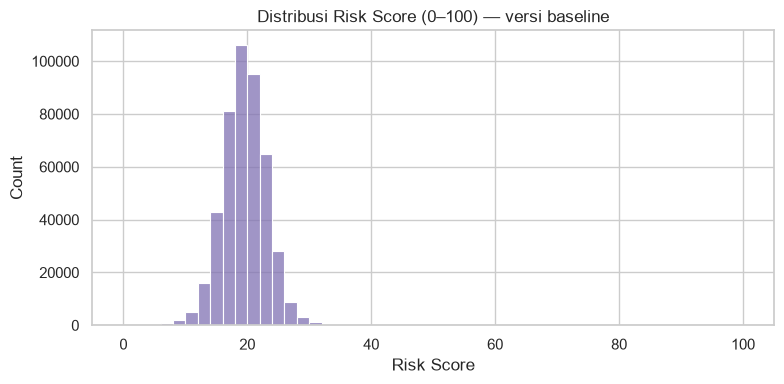

In [53]:
rr = unit["risk_raw"]
unit["risk_score"] = 100 * (rr - rr.min()) / (rr.max() - rr.min())

print(unit["risk_score"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(unit["risk_score"], bins=50, color="#8172B3")
plt.title("Distribusi Risk Score (0–100) — versi baseline")
plt.xlabel("Risk Score")
plt.tight_layout(); plt.show()

> 🙋 **Giliran Kalian — Normalisasi.** Perhatikan histogram di atas. Jika bentuknya sangat
> *skewed* (mayoritas nilai menumpuk di satu sisi), min–max langsung kurang ideal karena
> beberapa sel ekstrem menekan sisanya. Metode lain yang bisa kalian pertimbangkan &
> justifikasi: kompresi **`log1p`** sebelum scaling, **peringkat persentil**, atau *clipping*
> pada kuantil atas sebelum normalisasi. Bandingkan distribusinya dan pilih yang paling masuk
> akal untuk merepresentasikan "risiko".

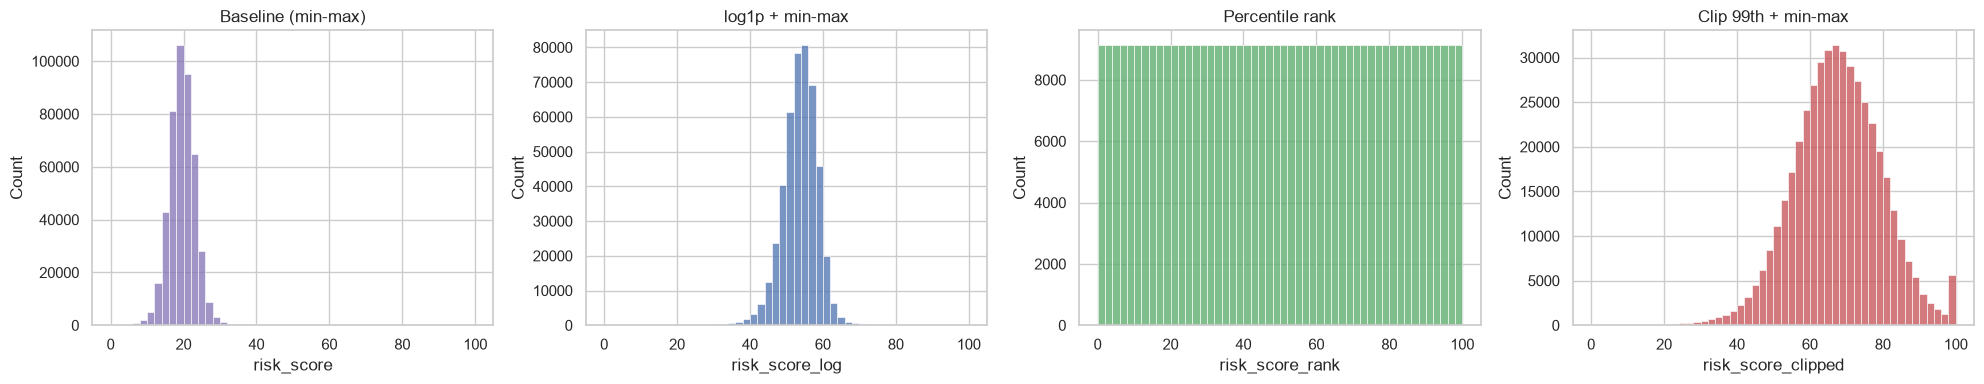

count    457696.00
mean         53.67
std           4.94
min           0.00
25%          50.85
50%          53.96
75%          56.87
max         100.00
Name: risk_score, dtype: float64


In [54]:
# Asumsi: min-max langsung (baseline) rentan outlier -- satu sel ekstrem bisa menekan
# semua sel lain mendekati 0. Kita bandingkan 3 alternatif, lalu pilih log1p sebagai versi
# final karena tetap mempertahankan urutan magnitude (beda dengan percentile rank yang
# menghilangkan info seberapa jauh perbedaannya).

# Opsi 1: log1p sebelum scaling -> menekan ekor kanan yang panjang
rr_log = np.log1p(unit["risk_raw"])
unit["risk_score_log"] = 100 * (rr_log - rr_log.min()) / (rr_log.max() - rr_log.min())

# Opsi 2: percentile rank -> paling robust thd outlier ekstrem, tapi mengabaikan magnitude asli
unit["risk_score_rank"] = unit["risk_raw"].rank(pct=True) * 100

# Opsi 3: clipping pada kuantil atas (99th percentile) lalu min-max
upper_clip = unit["risk_raw"].quantile(0.99)
rr_clipped = unit["risk_raw"].clip(upper=upper_clip)
unit["risk_score_clipped"] = 100 * (rr_clipped - rr_clipped.min()) / (rr_clipped.max() - rr_clipped.min())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.histplot(unit["risk_score"], bins=50, color="#8172B3", ax=axes[0]); axes[0].set_title("Baseline (min-max)")
sns.histplot(unit["risk_score_log"], bins=50, color="#4C72B0", ax=axes[1]); axes[1].set_title("log1p + min-max")
sns.histplot(unit["risk_score_rank"], bins=50, color="#55A868", ax=axes[2]); axes[2].set_title("Percentile rank")
sns.histplot(unit["risk_score_clipped"], bins=50, color="#C44E52", ax=axes[3]); axes[3].set_title("Clip 99th + min-max")
plt.tight_layout(); plt.show()

# Pilih versi final: log1p + min-max
unit["risk_score"] = unit["risk_score_log"]
unit.drop(columns=["risk_score_log", "risk_score_rank", "risk_score_clipped"], inplace=True)

print(unit["risk_score"].describe().round(2))

#### **Perbandingan Metode Normalisasi Risk Score**

Dari histogram perbandingan 4 metode normalisasi di atas, dapat disimpulkan
bahwa **`log1p + min-max` adalah metode terbaik** untuk merepresentasikan
Risk Score final:

**1. Baseline (min-max langsung)**
Distribusi masih sangat *skewed* --- mayoritas sel menumpuk di rentang
10--30, sementara sisanya nyaris kosong hingga ke 100. Ini membuktikan
masalah yang sudah diperingatkan di notebook: beberapa sel dengan
`risk_raw` ekstrem menekan seluruh sel lain ke rentang sempit, sehingga
sulit membedakan tingkat risiko antar-lokasi.

**2. `log1p + min-max` (dipilih sebagai versi final)**
Distribusi menjadi mendekati simetris/normal, berpusat di sekitar 50--60,
dan memanfaatkan rentang 0--100 secara jauh lebih merata. Yang terpenting,
**urutan magnitude tetap terjaga** --- sel dengan `risk_raw` yang jauh
lebih besar tetap memiliki skor lebih besar setelah transformasi, hanya
selisihnya yang dikompres. Sifat ini membuatnya paling representatif
sebagai fitur/label numerik untuk model regresi di Hands-On 2.

**3. Percentile rank**
Distribusi menjadi persis *uniform* (rata sempurna 0--100) --- ini memang
sifat alami dari rank. Namun metode ini **membuang informasi magnitude**:
dua sel dengan `risk_raw` yang beda tipis (persentil 49 vs 51) dianggap
"berbeda" sama besarnya dengan dua sel yang `risk_raw`-nya beda jauh
(persentil 10 vs 90). Untuk merepresentasikan "seberapa besar risiko",
ini kurang tepat --- lebih cocok dipakai kalau tujuannya sekadar
*ranking*/prioritas, bukan skor kontinu.

**4. Clip 99th + min--max**
Distribusi masih agak *skewed* ke kanan, dan muncul **spike artifisial
tepat di 100** --- ini adalah efek dari clipping: seluruh sel yang
awalnya berada di atas persentil ke-99 (padahal `risk_raw`-nya bervariasi)
dipepetkan menjadi nilai yang identik. Ironisnya, hal ini justru
menghilangkan detail pada sel-sel dengan risiko **tertinggi**, padahal
area itulah yang paling penting untuk dibedakan (mana hotspot yang benar-
benar paling gawat).


**Kesimpulan:** `log1p + min-max` dipilih sebagai metode normalisasi
final karena:
- Distribusi lebih simetris → representasi risiko lebih "adil" di
  seluruh rentang skor.
- Tidak menimbulkan *pileup* artifisial di salah satu ujung (berbeda
  dengan clipping).
- Tetap mempertahankan *ordering* magnitude asli dari `risk_raw`,
  berbeda dengan percentile rank yang menghilangkan informasi tersebut.

### Visualisasi peta risiko
Rata-rata Risk Score per sel — memastikan hasilnya sejalan dengan hotspot di EDA.

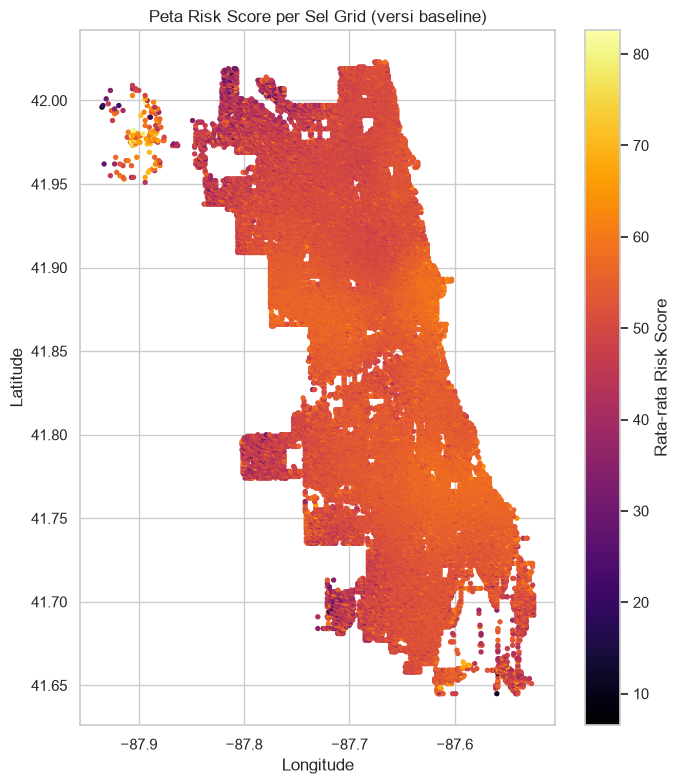

In [55]:
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi baseline)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

# 6. Menyusun & Menyimpan Dataset Akhir

Dataset akhir berisi **fitur + label** per unit analisis (sel × hari × jam), siap menjadi
input Hands-On 2 (modeling). Kita tambahkan fitur temporal **cyclical** pada level unit
agar langsung bisa dipakai model.

In [56]:
# Fitur temporal cyclical pada level unit.
# Catatan: kita bawa hour & dow (dipakai sebagai unit analisis). 'month' TIDAK ikut ke
# unit karena unit kita beragregasi per (sel × hari × jam) — bulan sudah "lebur" di dalamnya.
# Kalau kalian ingin bulan sebagai fitur, unit analisisnya perlu memasukkan bulan juga.
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"], 7)

final = unit[[
    # identitas / lokasi
    "cell_id", "lat_r", "lon_r",
    # fitur temporal (mentah + cyclical)
    "dow", "hour", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    # fitur agregat (frekuensi kejadian per unit)
    "crime_count",
    # LABEL
    "risk_score",
]].copy()

print("Shape dataset akhir:", final.shape)
final.head()

Shape dataset akhir: (457696, 11)


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,risk_score
0,41.649_-87.54,41.649,-87.540,0,0,0.0,1.0,0.0,1.0,2,66.290971
1,41.649_-87.546,41.649,-87.546,0,0,0.0,1.0,0.0,1.0,1,66.374471
2,41.651_-87.527,41.651,-87.527,0,0,0.0,1.0,0.0,1.0,1,65.433914
3,41.651_-87.545,41.651,-87.545,0,0,0.0,1.0,0.0,1.0,1,65.937822
4,41.652_-87.61,41.652,-87.610,0,0,0.0,1.0,0.0,1.0,1,58.659261


In [57]:
# Simpan ke CSV (selalu tersedia) + Parquet (lebih ringkas, jika engine tersedia)
final.to_csv("features_labels.csv", index=False)
print("Tersimpan: features_labels.csv ✅")

try:
    final.to_parquet("features_labels.parquet", index=False)
    print("Tersimpan: features_labels.parquet ✅")
except Exception as e:
    print("Parquet dilewati (engine belum terpasang) — CSV sudah cukup untuk HO2.")

Tersimpan: features_labels.csv ✅
Tersimpan: features_labels.parquet ✅


# 7. Ringkasan & Langkah Selanjutnya

Yang sudah kita hasilkan lewat **versi baseline** ini:
- **EDA** pola kejahatan lintas waktu & lokasi.
- **Fitur temporal** (cyclical encoding) & **spasial** (grid via pembulatan).
- **Risk Score (0–100)** via pseudo-labeling = *severity × temporal decay*, diagregasi
  per unit, dihaluskan antar-tetangga, lalu dinormalisasi.
- Dataset akhir `features_labels.*` — **siap dimodelkan** di Hands-On 2.

### ⚠️ Ingat: ini baru titik awal
Notebook ini sengaja memakai versi paling sederhana di tiap komponen inti. Ringkasan
**apa yang masih terbuka untuk kalian kembangkan** (dan inilah yang dinilai):

| Komponen | Versi baseline di tutorial | Ruang pengembangan kalian |
| :-- | :-- | :-- |
| Severity table | 5 kombinasi + 1 default | Perbanyak cakupan, fallback per-type, justifikasi skala |
| Temporal decay | Linear sederhana | Eksponensial/half-life? Parameter & justifikasi |
| Spatial | Rata-rata tetangga 3×3 (tanpa jarak) | Bobot berdasarkan jarak (BallTree/haversine), atur radius |
| Normalisasi | Min–max langsung | log1p / persentil / clipping outlier |
| Fitur | Minimal | Fitur agregat turunan, ukuran grid, penanda waktu |


> 🧠 **Inti penilaian:** dua komponen — **scoring table severity** dan **cara memodelkan
> relevansi waktu & lokasi** — dinilai dari **kekuatan justifikasi**, bukan dari menjalankan
> notebook ini apa adanya. Versi di sini sengaja mentah; buat versi kalian sendiri dan
> pertanggungjawabkan setiap keputusannya. Selamat mengerjakan! 🙂